# TP 2 — Premiers pas PySpark

**Big Data Engineering — Master 1 — DMI/FST/UCAD — Prof. Samba Ndiaye**

Ce notebook guide les parties B (WordCount), C (fil rouge) et D (Spark UI)
du TP 2. Complétez les cellules marquées `À COMPLÉTER`, exécutez tout de bout
en bout, puis poussez le notebook **avec ses sorties** dans `notebooks/`.

**Livrable** : ce notebook, avec le WordCount **commenté ligne à ligne**, les
observations de la Spark UI, et la comparaison Spark vs Pandas.

> Réflexe d'ingénieur : on ne dit pas « c'est lent », on dit « 4,2 s pour
> 50 000 lignes ». Mesurez tout.

## 0. Vérification de l'environnement

PySpark s'exécute sur la JVM : un **JDK 17** est requis. Si la cellule
échoue, revenez à la partie A du TP (`java -version`).

In [1]:
import sys, platform
import pyspark
print("Python  :", sys.version.split()[0], "-", platform.system())
print("PySpark :", pyspark.__version__)

Python  : 3.11.7 - Windows
PySpark : 3.5.1


## 1. Créer la SparkSession

`master("local[*]")` exécute Spark dans ce notebook, sur **tous les cœurs**
de la machine. La Spark UI démarre sur http://localhost:4040 — ouvrez-la.

In [2]:
from pyspark.sql import SparkSession

spark = (SparkSession.builder
         .appName("TP2-WordCount")
         .master("local[*]")
         .getOrCreate())

print("Spark", spark.version)
print("Coeurs vus :", spark.sparkContext.defaultParallelism)
print("Spark UI   :", spark.sparkContext.uiWebUrl)

Spark 3.5.1
Coeurs vus : 8
Spark UI   : http://SALIOU-MBACKE.mshome.net:4040


## Exercice B — WordCount

Préparez d'abord un fichier texte dans `data/discours.txt` (un discours, un
article — au moins quelques centaines de mots). La cellule ci-dessous compte
les mots. **Commentez chaque ligne** : c'est le cœur du livrable.

In [4]:
# === À COMPLÉTER ===
from pyspark.sql.functions import explode, split, lower, col

# Lit le fichier texte ligne par ligne
texte = spark.read.text("../data/discours.txt")

mots = (
    texte

    # Transforme chaque ligne en minuscules,
    # découpe la ligne en mots avec l'expression régulière \s+
    # puis explode crée une ligne par mot.
    .select(explode(split(lower(col("value")), r"\s+")).alias("mot"))

    # Supprime les mots vides
    .filter(col("mot") != "")

    # Regroupe les lignes par mot identique.
    # Cette opération provoque un shuffle car Spark doit
    # rassembler les mêmes mots provenant de différentes partitions.
    .groupBy("mot")

    # Compte le nombre d'occurrences de chaque mot
    .count()
)

# Trie les mots par fréquence décroissante et affiche les 15 premiers
mots.orderBy(col("count").desc()).show(15)

+--------------+-----+
|           mot|count|
+--------------+-----+
|            de|   22|
|             à|   14|
|           des|   13|
|            et|   13|
|            la|   12|
|           les|   11|
|l’intelligence|   10|
|  artificielle|   10|
|          elle|    7|
|          dans|    6|
|           une|    6|
|            en|    5|
|          peut|    5|
|            le|    5|
|         notre|    4|
+--------------+-----+
only showing top 15 rows



### B — Observer (répondez en markdown)

1. Quelles lignes sont des **transformations** ? Laquelle est l'**action** ?
2. Où se situe le **shuffle** ?
3. Si vous relancez `mots.orderBy(...).show()`, pourquoi tout est-il
   recalculé ?

*Vos réponses :* …
1. Quelles lignes sont des transformations ? Laquelle est l'action ?

Réponse :

Les transformations sont :

spark.read.text("../data/discours.txt")
.select(...)
.filter(...)
.groupBy("mot")
.count()
.orderBy(...)


Ces opérations construisent un plan d'exécution mais ne lancent pas immédiatement le calcul.

L'action est :

.show(15)

C'est cette instruction qui déclenche réellement l'exécution du programme.

2. Où se situe le shuffle ?

Réponse :

Le shuffle se produit lors de :

.groupBy("mot")

En effet, Spark doit redistribuer les données entre les partitions afin que toutes les occurrences d'un même mot soient regroupées avant le comptage.


3. Si vous relancez mots.orderBy(...).show(), pourquoi tout est-il recalculé ?

Réponse :

Spark applique le principe de l'évaluation paresseuse (Lazy Evaluation). Les transformations ne sont pas exécutées immédiatement et les résultats ne sont pas conservés en mémoire par défaut. À chaque nouvel appel de show(), Spark relit le fichier et réexécute toutes les transformations.


## Exercice C — Recharger le fil rouge avec Spark

On reprend les fichiers du fil rouge, cette fois avec Spark. `inferSchema`
demande à Spark de **deviner** les types (pratique mais coûteux : une passe
de lecture en plus).

In [5]:
# === À COMPLÉTER ===
#../data/ pour remonter d'un dossier a partir du notebook pour atteindre le dossier data ici
#chargement du jeu de donnees excel orders.csv avec spark
orders = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv("../data/orders.csv")
)

events = spark.read.json("../data/events.json")   # JSON Lines chargement du fichier json(event.json avec spark)

# Afficher le schéma des commandes
orders.printSchema()

# Afficher le nombre de lignes
print("orders :", orders.count()," lignes")

# Afficher le schéma des événements
events.printSchema()

root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- date_commande: timestamp (nullable = true)
 |-- statut: string (nullable = true)
 |-- canal: string (nullable = true)
 |-- frais_livraison_fcfa: integer (nullable = true)
 |-- montant_total_fcfa: string (nullable = true)

orders : 50000  lignes
root
 |-- device: string (nullable = true)
 |-- event_id: string (nullable = true)
 |-- event_time: string (nullable = true)
 |-- event_type: string (nullable = true)
 |-- order_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- session_id: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- ville: string (nullable = true)



### C — Explorer sans tout rapatrier

`show(n)` et `count()` sont des actions ; `select`, `filter`, `groupBy`
décrivent seulement le plan. **Ne jamais** faire `events.collect()`.

In [6]:
# === À COMPLÉTER ===
from pyspark.sql.functions import col, desc

# Sélectionne uniquement les colonnes order_id, statut et canal
orders.select("order_id", "statut", "canal").show(5)

# Filtre uniquement les commandes dont le statut est "livree"
livrees = orders.filter(col("statut") == "livree")

# Action : compte le nombre de commandes livrées
print("livrees :", livrees.count())

# Regroupe les commandes par statut et compte le nombre de commandes
# pour chaque statut
orders.groupBy("statut").count().show()

# Regroupe les commandes par canal (Web, Mobile, Magasin, ...)
# puis compte le nombre de commandes pour chaque canal
# Trie ensuite les résultats par nombre de commandes décroissant
(
    orders.groupBy("canal")
          .count()
          .orderBy(desc("count"))
          .show()
)

+--------+-------+----------+
|order_id| statut|     canal|
+--------+-------+----------+
|O0000001| livrée|mobile_app|
|O0000002| livrée|mobile_app|
|O0000003| livrée|       web|
|O0000004| livrée|mobile_app|
|O0000005|annulée|       web|
+--------+-------+----------+
only showing top 5 rows

livrees : 0
+---------+-----+
|   statut|count|
+---------+-----+
|retournée| 2484|
|   livrée|38890|
| en_cours| 4058|
|  annulée| 4568|
+---------+-----+

+----------+-----+
|     canal|count|
+----------+-----+
|mobile_app|32519|
|       web|17481|
+----------+-----+



## Exercice C.3 — Spark vs Pandas : mesurez

Chronométrez Spark sur `orders.csv`, comparez à votre mesure Pandas du TP 1
(même fichier, échelle 0.1). Lequel gagne sur ce petit volume ?

In [7]:
# === À COMPLÉTER ===
import time

import time

# Démarre le chronomètre
t0 = time.perf_counter()

# Lit le fichier CSV avec Spark puis compte le nombre de lignes
n = (
    spark.read
    .option("header", True)
    .csv("../data/orders.csv")
    .count()
)

# Calcule le temps écoulé
t_spark = time.perf_counter() - t0

# Affiche le temps d'exécution et le nombre de lignes
print("Spark : %.2f s pour %d lignes" % (t_spark, n))

#temps obtenu avec Pandas dans le TP1
t_pandas = 0.11  

print("Pandas (TP1) : %.2f s" % t_pandas)

Spark : 0.67 s pour 50000 lignes
Pandas (TP1) : 0.11 s


## Comparaison pandas vs spark

Sur ce petit volume de données, Pandas gagne. Il est plus rapide (0,11 s contre 0,67 s pour Spark), car Spark doit d'abord initialiser son moteur d'exécution, ce qui ajoute un coût fixe.

## Exercice D — Lire la Spark UI

Ouvrez http://localhost:4040. Cette cellule donne les partitions ; le reste
s'observe **dans le navigateur** (onglets Jobs, Stages, SQL/DataFrame).

In [9]:
# === À COMPLÉTER ===
print("Partitions orders :", orders.rdd.getNumPartitions())
print("Coeurs disponibles :", spark.sparkContext.defaultParallelism)

# Relancez le WordCount pour le retrouver dans l'onglet Jobs :
mots.orderBy(col("count").desc()).show(5)

Partitions orders : 1
Coeurs disponibles : 8
+---+-----+
|mot|count|
+---+-----+
| de|   22|
|  à|   14|
| et|   13|
|des|   13|
| la|   12|
+---+-----+
only showing top 5 rows



### D — Relevés (complétez en markdown)

- Nombre de stages du WordCount : 1
- Shuffle Read / Write du stage d'agrégation :
      -shuffle Read: 5.0 KiB
      -shuffle Write: 0 KiB
- Nombre de tasks par stage / nombre de partitions : 1 task
- Tasks en parallèle vs nombre de cœurs : 1 task pour 8 cœurs disponibles

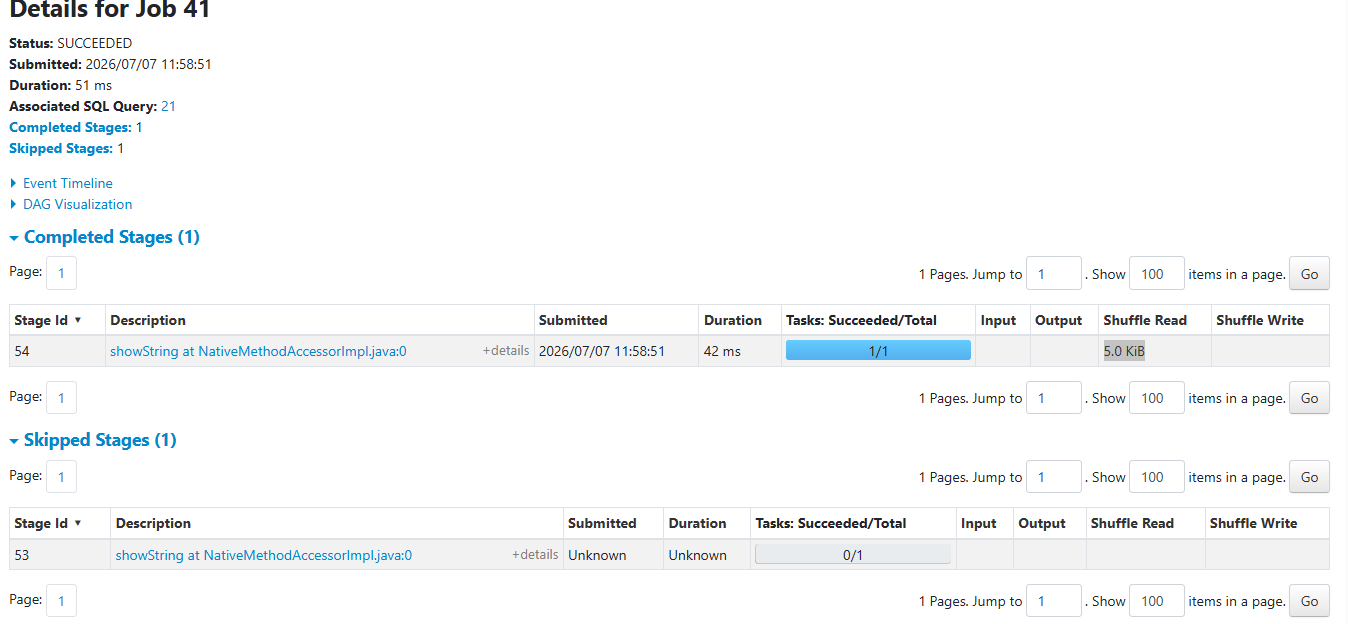

## 5. Avant de pousser

Vérifiez : WordCount commenté ligne à ligne, observations Spark UI
renseignées, comparaison Spark/Pandas chiffrée. Puis :

```bash
git add notebooks/TP2_wordcount.ipynb
git commit -m "TP2 : WordCount PySpark, fil rouge, Spark UI"
git push
```

Pensez à **arrêter la session** en fin de travail : `spark.stop()`.

In [10]:
spark.stop()